In [1]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, BatchNormalization, GRU, Input, Flatten, Dropout, Activation, Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Model evaluation
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

import keras
from keras.preprocessing import sequence
from keras.preprocessing.sequence import pad_sequences

In [2]:
data_folder = 'datasets_combined_augmented'

# Paths to your previously saved files
X_train = np.load(f'../{data_folder}/X_deep_train.npy')
y_train = np.load(f'../{data_folder}/y_deep_train.npy')
X_val = np.load(f'../{data_folder}/X_deep_val.npy')
y_val = np.load(f'../{data_folder}/y_deep_val.npy')
X_test = np.load(f'../{data_folder}/X_deep_test.npy')
y_test = np.load(f'../{data_folder}/y_deep_test.npy')

In [3]:
# Suppose y_train, y_val, y_test are like [1, 2, 3, 4, 5, 6, 7, 8]
# Convert them to zero-based labels (required for to_categorical)
y_train_enc = y_train - 1
y_val_enc = y_val - 1
y_test_enc = y_test - 1

# Get number of classes automatically
num_classes = np.max(y_train_enc) + 1

# Convert to one-hot (instead of labels being a single integer, converts it to a binary vector)
# e.g. if happy = 2, it will be represented like this -> [0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train_enc, num_classes)
y_val_cat = to_categorical(y_val_enc, num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes)

# --- Get shape info for the model ---
time_steps = X_train.shape[1]
num_features = X_train.shape[2]

print(f"Time steps: {time_steps}, Num features: {num_features}, Classes: {num_classes}")

Time steps: 483, Num features: 92, Classes: 7


In [4]:
# --- Normalize features ---
# compute mean and sd from the train data
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

# standardize
X_train = (X_train - mean) / (std)
X_val = (X_val - mean) / (std)
X_test = (X_test - mean) / (std)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers as L

# Input shape: (timesteps, features)
input_shape = (X_train.shape[1], X_train.shape[2])

model = tf.keras.Sequential([
    # --- CNN Block 1 ---
    L.Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=input_shape),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, strides=2, padding='same'),

    # --- CNN Block 2 ---
    L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, strides=2, padding='same'),
    L.Dropout(0.2),

    # --- CNN Block 3 ---
    L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2, strides=2, padding='same'),
    L.Dropout(0.2),

    # --- BiLSTM Block ---
    L.Bidirectional(L.LSTM(128, return_sequences=False)),
    L.Dropout(0.3),

    # --- Dense Block ---
    L.Dense(256, activation='relu'),
    L.Dropout(0.3),
    L.Dense(128, activation='relu'),

    # --- Output ---
    L.Dense(7, activation='softmax')  # 7 emotion classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 483, 128)       │        59,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 483, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 242, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 242, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 242, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 121, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 121, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 121, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 121, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 61, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,727 (2.68 MB)

 Trainable params: 701,703 (2.68 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [6]:
callbacks = [
    EarlyStopping(
        patience=10,                # stop if val_loss doesn't improve for 10 epochs
        restore_best_weights=True   # revert to best model
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',    # file to save the best model
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

In [7]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,             # upper limit — early stopping will likely end before this
    batch_size=64,         # number of samples per gradient update
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 163s 375ms/step - accuracy: 0.4746 - loss: 1.2933 - val_accuracy: 0.5690 - val_loss: 1.0710 - learning_rate: 0.0010
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 142s 356ms/step - accuracy: 0.6080 - loss: 1.0103 - val_accuracy: 0.6027 - val_loss: 1.0315 - learning_rate: 0.0010
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 142s 356ms/step - accuracy: 0.6641 - loss: 0.8901 - val_accuracy: 0.6316 - val_loss: 0.9352 - learning_rate: 0.0010
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 143s 358ms/step - accuracy: 0.7095 - loss: 0.7791 - val_accuracy: 0.6534 - val_loss: 0.8798 - learning_rate: 0.0010
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 143s 358ms/step - accuracy: 0.7392 - loss: 0.7005 - val_accuracy: 0.6730 - val_loss: 0.8517 - learning_rate: 0.0010
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 139s 347ms/step - accuracy: 0.7749 - loss: 0.6181 - val_accuracy: 0.6687 - val_loss: 0.9289 - learning_rate: 0.0010
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 137s 343ms/step - accura

In [8]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.2%}")

✅ Test Accuracy: 69.08%


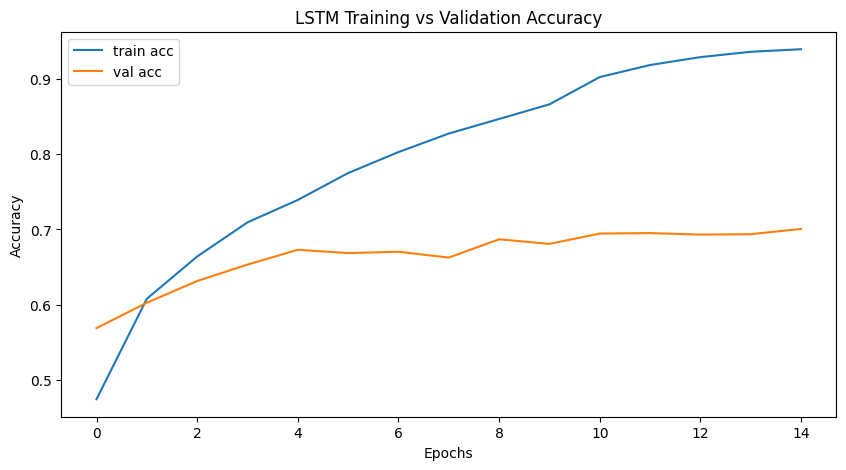

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Training vs Validation Accuracy')
plt.show()